In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns

In [18]:
arena_mask = np.array([
    [-1, -1, -1,  0,  1],
    [ 2,  3,  4,  5,  6],
    [ 7,  8,  9, 10, 11],
    [-1, -1, -1, 12, 13]
])

def map_coordinates_to_cell(x, y, x_min, x_max, y_min, y_max):
    n_rows = 4
    n_cols = 5
    

    x_norm = np.clip((x - x_min) / (x_max - x_min), 0, 0.999)
    y_norm = np.clip((y - y_min) / (y_max - y_min), 0, 0.999)
    
    col_idx = int(np.floor(x_norm * n_cols))
    row_idx = int(np.floor(y_norm * n_rows))
    
    cell_id = arena_mask[row_idx, col_idx]
     
    if cell_id == -1:
        return np.nan 
    return cell_id

In [19]:
mice = [i for i in range(13, 21)]

mouse_num = mice[1]
day = 3
day_num = day + 7
df = pd.read_csv(f'./dlc/d{day_num}_m{mouse_num}_investigation_cropped.csv', index_col=0)

confidence_threshold = 0.8
df = df[df['Center_p'] > confidence_threshold]

df.head()

,Ear_left_x,Ear_left_y,Ear_left_p,Ear_right_x,Ear_right_y,Ear_right_p,Nose_x,Nose_y,Nose_p,Center_x,...,Corridor Animal_1 in zone_cumulative_percent,Shelter Animal_1 in zone,Shelter Animal_1 in zone_cumulative_time,Shelter Animal_1 in zone_cumulative_percent,Chamber Animal_1 distance,Corridor Animal_1 distance,Shelter Animal_1 distance,Chamber Animal_1 facing,Corridor Animal_1 facing,Shelter Animal_1 facing
0,160.00000,258.00000,0.998128,152.00000,288.00000,0.997631,172.00000,282.00000,0.986582,97.000000,...,1.0,1,0.04,1.0,711.86584,239.45981,295.60107,1,1,0
1,163.00000,259.00000,0.998099,153.00000,289.00000,0.998862,173.00000,283.00000,0.978980,98.000000,...,1.0,1,0.08,1.0,711.54060,238.47852,294.80330,1,1,0
2,162.63190,259.20392,0.997973,152.80795,289.99588,0.998781,173.20393,283.59990,0.982495,98.599910,...,1.0,1,0.12,1.0,711.34607,237.88990,294.32532,1,1,0
3,163.39598,259.79608,0.997897,153.19205,290.81207,0.999079,173.60402,284.59213,0.982349,99.208046,...,1.0,1,0.16,1.0,710.96760,237.25612,293.95760,1,1,0
4,164.16418,260.20392,0.997495,153.97212,291.42386,0.999213,174.38410,284.83170,0.985569,99.807950,...,1.0,1,0.20,1.0,710.76263,236.66522,293.48795,1,1,0


In [20]:
min_x, max_x = df['Center_x'].min(), df['Center_x'].max()
min_y, max_y = df['Center_y'].min(), df['Center_y'].max()
width = max_x - min_x
height = max_y - min_y
aspect_ratio = height / width

print(f"Arena Dimensions: W={width:.1f}, H={height:.1f}")
print(f"Aspect Ratio (H/W): {aspect_ratio:.3f}")

n_rows = 5
n_cols = int(np.round(n_rows / aspect_ratio))

print(f'grid shape: ({n_rows} x {n_cols})')

Arena Dimensions: W=1053.0, H=376.0
Aspect Ratio (H/W): 0.357
grid shape: (5 x 14)


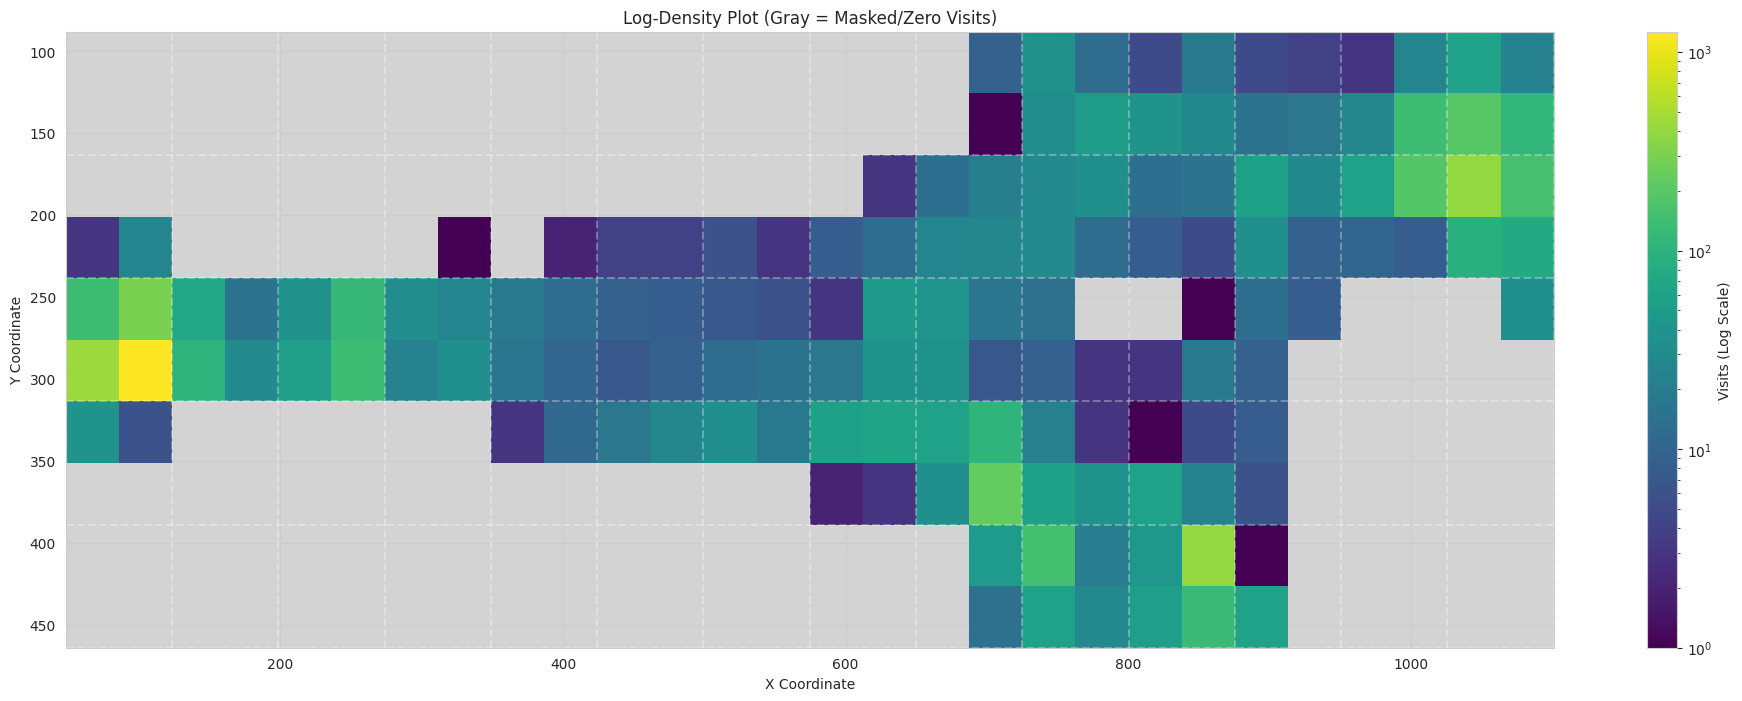

In [21]:
plt.figure(figsize=(24, 8))
ax = plt.gca()
ax.set_facecolor('lightgray') 


counts, xedges, yedges, image = plt.hist2d(
    df['Center_x'], df['Center_y'], 
    bins=[n_cols*2, n_rows*2],
    norm=colors.LogNorm(),
    cmap='viridis',
    cmin=1
)


x_grid = np.linspace(df['Center_x'].min(), df['Center_x'].max(), n_cols + 1)
y_grid = np.linspace(df['Center_y'].min(), df['Center_y'].max(), n_rows + 1)

for x in x_grid:
    plt.axvline(x, color='white', linestyle='--', alpha=0.3)
for y in y_grid:
    plt.axhline(y, color='white', linestyle='--', alpha=0.3)

%matplotlib inline
plt.colorbar(image, label='Visits (Log Scale)')
plt.gca().invert_yaxis()
plt.title(f"Log-Density Plot (Gray = Masked/Zero Visits)")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")

plt.show()

In [37]:
final_mask = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
])

# 2. Pre-calculate active cell coordinates and mapping
# np.argwhere finds indices in row-major order (Row 0 first, then 1, etc.)
active_cells = np.argwhere(final_mask == 1) 
# Create a dictionary to map (row, col) to a zero-indexed bin ID (0-56)
bin_id_map = {tuple(pos): i for i, pos in enumerate(active_cells)}

def get_closest_bin(r, c):
    """Finds the nearest cell with a '1' if the current cell is '0'."""
    if final_mask[r, c] == 1:
        return bin_id_map[(r, c)]
    
    # Calculate Euclidean distance to all active cells
    distances = np.sum((active_cells - np.array([r, c]))**2, axis=1)
    nearest_idx = np.argmin(distances)
    nearest_r, nearest_c = active_cells[nearest_idx]
    
    return bin_id_map[(nearest_r, nearest_c)]

# 3. Processing the data
# Filter for high confidence
df_filtered = df.copy()

# Coarse-grain into 2000 steps
df_filtered['step_number'] = np.linspace(0, 2200, len(df_filtered), endpoint=False).astype(int)

# Aggregate mean position per step
coarse_data = df_filtered.groupby('step_number').agg({
    'Center_x': 'mean',
    'Center_y': 'mean'
}).reset_index()

# Define boundaries
min_x, max_x = df_filtered['Center_x'].min(), df_filtered['Center_x'].max()
min_y, max_y = df_filtered['Center_y'].min(), df_filtered['Center_y'].max()
n_rows, n_cols = 5, 15

def map_position(row):
    # Normalize and find raw grid coordinates
    x_norm = np.clip((row['Center_x'] - min_x) / (max_x - min_x), 0, 0.999)
    y_norm = np.clip((row['Center_y'] - min_y) / (max_y - min_y), 0, 0.999)
    
    r = int(np.floor(y_norm * n_rows))
    c = int(np.floor(x_norm * n_cols))
    
    # Return the mapped bin ID using nearest-neighbor logic
    return get_closest_bin(r, c)

# 4. Generate final table
coarse_data['location'] = coarse_data.apply(map_position, axis=1)
final_table = coarse_data[['step_number', 'location']]

print(final_table.head())

   step_number  location
0            0        53
1            1        53
2            2        53
3            3        53
4            4        53


In [36]:
final_table['step_number'][0]

np.int64(0)

In [38]:
# 1. Re-calculate active_cells coordinates to map IDs back to (r, c)
# This uses the same logic as the mapping step
active_cells = np.argwhere(final_mask == 1)

# 2. Get the coordinates for every step in your table
# We use the location ID as an index into the active_cells array
current_coords = active_cells[final_table['location'].values]

# 3. Calculate the distance between consecutive steps
# diff[i] = coord[i+1] - coord[i]
diffs = np.diff(current_coords, axis=0)
abs_diffs = np.abs(diffs)

# 4. Identify "jumps"
# A jump occurs if the mouse moves more than 1 bin in any direction 
# (i.e., if max(abs(dr), abs(dc)) > 1)
jumps_mask = np.any(abs_diffs > 1, axis=1)
jump_indices = np.where(jumps_mask)[0]
num_jumps = len(jump_indices)

print(f"Total transitions analyzed: {len(diffs)}")
print(f"Number of non-neighbor jumps: {num_jumps}")

if num_jumps > 0:
    print("\nFirst 5 jump examples (Step -> From Bin -> To Bin):")
    for idx in jump_indices[:]:
        from_bin = final_table['location'].iloc[idx]
        to_bin = final_table['location'].iloc[idx + 1]
        print(f"Step {idx} to {idx+1}: Bin {from_bin} to Bin {to_bin}")
else:
    print("\nSuccess! The mouse trajectory is continuous at this time resolution.")

Total transitions analyzed: 2199
Number of non-neighbor jumps: 11

First 5 jump examples (Step -> From Bin -> To Bin):
Step 48 to 49: Bin 44 to Bin 27
Step 50 to 51: Bin 26 to Bin 24
Step 229 to 230: Bin 29 to Bin 27
Step 348 to 349: Bin 27 to Bin 25
Step 349 to 350: Bin 25 to Bin 23
Step 379 to 380: Bin 24 to Bin 26
Step 449 to 450: Bin 28 to Bin 26
Step 694 to 695: Bin 27 to Bin 25
Step 696 to 697: Bin 24 to Bin 22
Step 1802 to 1803: Bin 28 to Bin 26
Step 2085 to 2086: Bin 14 to Bin 27


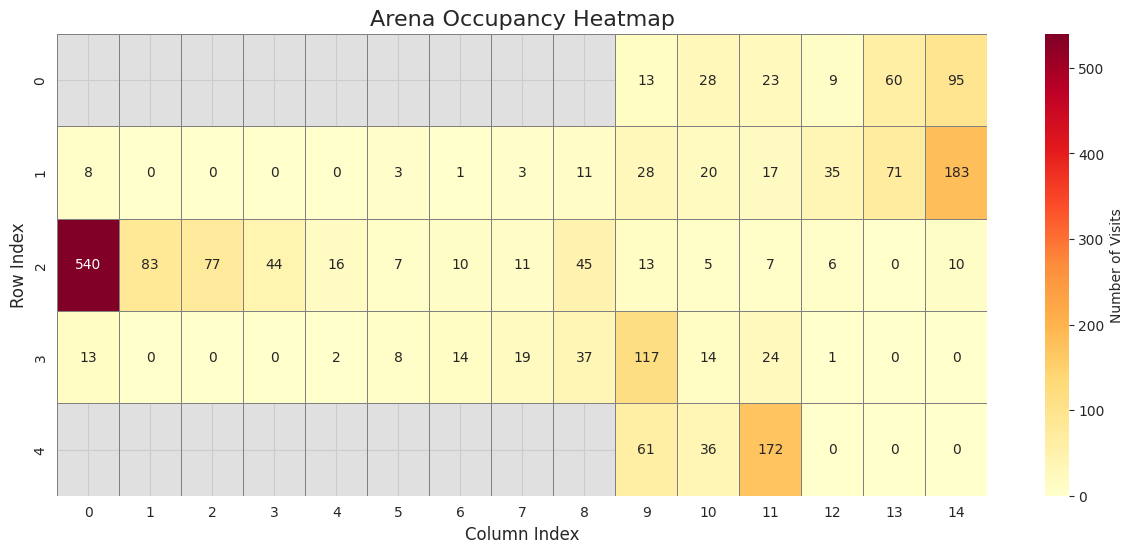

In [24]:

# 1. Define the arena structure and active cells
final_mask = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
])
active_cells = np.argwhere(final_mask == 1)

# 2. Count the visits for each bin ID in your final_table
visit_counts = final_table['location'].value_counts()

# 3. Create a 5x15 grid for the heatmap and fill it with counts
heatmap_grid = np.zeros((5, 15))
for bin_id, count in visit_counts.items():
    # Map the bin ID (0-56) to its corresponding (row, col)
    r, c = active_cells[bin_id]
    heatmap_grid[r, c] = count

# 4. Generate the plot
plt.figure(figsize=(15, 6))
# Mask out the inactive bins (where the mask is 0)
plot_mask = (final_mask == 0)

ax = sns.heatmap(heatmap_grid, mask=plot_mask, annot=True, fmt=".0f", 
                 cmap="YlOrRd", cbar_kws={'label': 'Number of Visits'}, 
                 linewidths=0.5, linecolor='gray')

# Style the background for inactive masked areas
ax.set_facecolor('#e0e0e0') 

plt.title("Arena Occupancy Heatmap", fontsize=16)
plt.xlabel("Column Index", fontsize=12)
plt.ylabel("Row Index", fontsize=12)

plt.show()

In [25]:
import numpy as np
import pandas as pd

# 1. Configuration and Target Bins
mice = [i for i in range(13, 21)]
day = 1
day_num = day + 7
target_bins = {49, 50, 55, 56}
num_steps = 2000

# 2. Define the fixed 5x15 arena mask and active cell mapping
final_mask = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
])
active_cells = np.argwhere(final_mask == 1)
n_rows, n_cols = 5, 15

def get_closest_bin_id(r, c):
    """Finds the nearest active bin ID."""
    if final_mask[r, c] == 1:
        # Find index in active_cells
        return np.where((active_cells == [r, c]).all(axis=1))[0][0]
    # Otherwise, find the Euclidean nearest neighbor
    distances = np.sum((active_cells - np.array([r, c]))**2, axis=1)
    return np.argmin(distances)

# 3. Analyze each mouse
visit_summary = []

for mouse_num in mice:
    try:
        # Load and Filter
        df = pd.read_csv(f'./dlc/d{day_num}_m{mouse_num}_investigation_cropped.csv', index_col=0)
        df = df[df['Center_p'] > 0.8].copy()
        
        # Coarse-grain into steps
        df['step_number'] = np.linspace(0, num_steps, len(df), endpoint=False).astype(int)
        coarse_data = df.groupby('step_number').agg({'Center_x': 'mean', 'Center_y': 'mean'})
        
        # Get boundaries for this specific file
        min_x, max_x = df['Center_x'].min(), df['Center_x'].max()
        min_y, max_y = df['Center_y'].min(), df['Center_y'].max()
        
        # Map to Bins
        def map_step(row):
            x_norm = np.clip((row['Center_x'] - min_x) / (max_x - min_x), 0, 0.999)
            y_norm = np.clip((row['Center_y'] - min_y) / (max_y - min_y), 0, 0.999)
            r, c = int(y_norm * n_rows), int(x_norm * n_cols)
            return get_closest_bin_id(r, c)

        coarse_data['location'] = coarse_data.apply(map_step, axis=1)
        
        # Check for target visits
        visited = set(coarse_data['location']).intersection(target_bins)
        
        if visited:
            visit_summary.append({
                'mouse': mouse_num,
                'visited_bins': sorted(list(visited)),
                'status': 'YES'
            })
        else:
            visit_summary.append({
                'mouse': mouse_num,
                'visited_bins': [],
                'status': 'NO'
            })
            
    except FileNotFoundError:
        print(f"File for mouse {mouse_num} not found.")

# 4. Results
results_df = pd.DataFrame(visit_summary)
print(f"--- Visit Summary for Day {day} (Bottom 4 Bins) ---")
print(results_df)

--- Visit Summary for Day 1 (Bottom 4 Bins) ---
   mouse visited_bins status
0     13           []     NO
1     14           []     NO
2     15           []     NO
3     16           []     NO
4     17           []     NO
5     18           []     NO
6     19           []     NO
7     20           []     NO


In [26]:
import numpy as np
import pandas as pd

# 1. Configuration
mice = [i for i in range(13, 21)]
day = 1
day_num = day + 7
num_steps = 2000

# Bin sets defined by distance
dist1_bins = {33, 34, 35, 48, 54}
dist2_bins = {17, 18, 19, 20, 32, 47, 53}

# 2. Define the fixed 5x15 arena mask and active cell mapping
final_mask = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
])
active_cells = np.argwhere(final_mask == 1)
n_rows, n_cols = 5, 15

def get_closest_bin_id(r, c):
    """Maps normalized row/col to the nearest active bin ID."""
    if final_mask[r, c] == 1:
        return np.where((active_cells == [r, c]).all(axis=1))[0][0]
    # Euclidean nearest neighbor for points outside the mask
    distances = np.sum((active_cells - np.array([r, c]))**2, axis=1)
    return np.argmin(distances)

# 3. Analyze each mouse
results = []

for mouse_num in mice:
    try:
        # Load and Filter
        file_path = f'./dlc/d{day_num}_m{mouse_num}_investigation_cropped.csv'
        df = pd.read_csv(file_path, index_col=0)
        df = df[df['Center_p'] > 0.8].copy()
        
        # Coarse-grain into 2000 steps
        df['step_number'] = np.linspace(0, num_steps, len(df), endpoint=False).astype(int)
        coarse_data = df.groupby('step_number').agg({'Center_x': 'mean', 'Center_y': 'mean'})
        
        # Get boundaries for normalization
        min_x, max_x = df['Center_x'].min(), df['Center_x'].max()
        min_y, max_y = df['Center_y'].min(), df['Center_y'].max()
        
        # Map to Bin IDs
        def map_step(row):
            x_norm = np.clip((row['Center_x'] - min_x) / (max_x - min_x), 0, 0.999)
            y_norm = np.clip((row['Center_y'] - min_y) / (max_y - min_y), 0, 0.999)
            r, c = int(y_norm * n_rows), int(x_norm * n_cols)
            return get_closest_bin_id(r, c)

        coarse_data['location'] = coarse_data.apply(map_step, axis=1)
        
        # Count visits to each distance set
        d1_counts = coarse_data['location'].isin(dist1_bins).sum()
        d2_counts = coarse_data['location'].isin(dist2_bins).sum()
        
        results.append({
            'Mouse': mouse_num,
            'Dist_1_Visits': d1_counts,
            'Dist_2_Visits': d2_counts
        })
            
    except FileNotFoundError:
        results.append({
            'Mouse': mouse_num,
            'Dist_1_Visits': 'File Not Found',
            'Dist_2_Visits': 'File Not Found'
        })

# 4. Display Summary Table
summary_df = pd.DataFrame(results)
print(f"--- Visit Counts for Day {day} (Total Steps = {num_steps}) ---")
print(summary_df.to_string(index=False))

--- Visit Counts for Day 1 (Total Steps = 2000) ---
 Mouse  Dist_1_Visits  Dist_2_Visits
    13             27            260
    14              5            225
    15             25            154
    16             98            739
    17            104            374
    18             56            270
    19            188            263
    20            123            646


In [ ]:
import numpy as np

def calculate_social_investigation(trajectory, threat_zone_coords):
    """
    trajectory: List of (row, col) tuples (from Model OR DLC)
    threat_zone_coords: List of (r, c) tuples defining the threat object (the 4 bins)
    """
    investigation_time = 0
    total_time = len(trajectory)
    
    for agent_pos in trajectory:
        # 1. Calculate Euclidean distance to the CLOSEST threat bin
        # We use standard Euclidean (L2) distance here, regardless of model physics
        dists = [np.sqrt((agent_pos[0] - t[0])**2 + (agent_pos[1] - t[1])**2) 
                 for t in threat_zone_coords]
        
        min_euclidean_dist = min(dists)
        
        # 2. Apply the Manual Scoring Definition
        # "Euclidean distance <= 2 from the bottom 4 bins"
        if min_euclidean_dist <= 2.0:
            investigation_time += 1
            
    return investigation_time / total_time

# METRIC USAGE
# For Model:
threat_bins = [(3, 13), (3, 14), (4, 13), (4, 14)]
model_score = calculate_social_investigation(history['loc'], threat_bins)

# For Real Data (assuming you binned it to the same grid):
real_score = calculate_social_investigation(real_mouse_binned_traj, threat_bins)